# **Access and analyze pre-calculated climate indicators for an ensemble of climate simulations**

This notebook shows you how to access and process pre-calculated climate indicators for climate model ensembles such as `CanDCS-M6` ([climatedata.ca](https://climatedata.ca/resource/intro-to-candcs-m6/)). You will learn how to filter them by scenario and variable, and how to subset them to a polygon region. The notebook then walks through common processing steps, including computing 30-year climatological means, anomalies/deltas relative to a reference period, spatial averages, and ensemble percentiles. The processed results are saved to Zarr files and also exported to CSV for downstream analysis. You can explore and visualize the processed data directly in this notebook or download the CSV file and open it in tools such as Excel.

The example in **Step 8** illustrates how to analyze and visualize the total precipitation data extracted in the previous steps. The default data selections in **Step 1 (basic inputs)** and **Step 4 (choice of indicators)** are configured to support this example. You can modify the code in **Steps 1, 4 and 8** to adapt the workflow to your own variables, regions, scenarios, and periods of interest. 

You can also upload your own polygon files (for example, your own shapefiles or GeoJSONs) and modify the `polygon_file` path in **Step 1** accordingly to run the same analysis for your own regions.

### **Step 0 – Imports & configuration**

Run this cell once at the very beginning of the notebook. You don't need to modify anything inside it. It just loads the Python packages and sets some technical options.


In [46]:
from pathlib import Path
import logging
import shutil
import warnings

import geopandas as gpd
import hvplot.pandas
import hvplot.xarray
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import panel as pn
import threddsclient as tds
import xarray as xr
import yaml
from IPython.display import Markdown, clear_output
from dask.diagnostics import ProgressBar
from dask.distributed import Client
from xclim.core.units import convert_units_to
from xscen import ensembles as xens
from xscen.aggregate import climatological_op, compute_deltas, spatial_mean
from xscen.io import save_to_zarr
from xscen.spatial import subset
from xscen.utils import unstack_dates

warnings.simplefilter("ignore")
pn.extension("tabulator")

# Dask cluster configuration used when writing Zarr files
dask_kwargs = dict(
    n_workers=6,
    threads_per_worker=10,
    memory_limit="3GB",
    dashboard_address=8787,
    silence_logs=logging.ERROR,
)

print("Setup done. You can move to Step 1.")

Setup done. You can move to Step 1.


### **Step 1 – Choose the dataset, region, and options**


First, specify which ensemble of simulations to use for the pre-calculated climate indicators. For this tutorial, we work with the `CanDCS-M6` ensemble from climatedata.ca, hosted on the PAVICS / [THREDDS server](https://pavics.ouranos.ca/twitcher/ows/proxy/thredds/catalog/catalog.html), but you can later adapt the same workflow to other ensembles (e.g., `ESPO-G6-R2`, which is the data behind Ouranos' Climate Portraits site).

In [21]:
# this dictionnary specifies the THREDDS catalog URL where the data for CanDCS-M6 can be found, and
# a preferred chunking strategy used when loading the data with Dask (this helps performance and memory).
pavics_url = {
    "CanDCS-M6": {
        "url":"https://pavics.ouranos.ca/twitcher/ows/proxy/thredds/catalog/datasets/simulations/bias_adjusted/cmip6/climatedata_ca/CanDCS-M6/ensemble_members/timeseries/catalog.html",
        "chunks": dict(realization=1, time=-1, lon=30 * 5, lat=30 * 5), # preferred chunking for loading the data
    },
}

After that, specify which region and settings you want for the data extraction. The inputs below are set to support the example in Step 8; you can modify them according to your analysis needs.


- `data_source` : which ensemble to use (e.g., `"CanDCS-M6"`)
- `polygon_file` : the path to the shapefile / GeoJSON defining your region.
- `spatial_avg` : set to `True` to compute the spatial of average of the grid cells inside each polygon.
- `time_avg` : set to `True` to create 30-year climatological means and anomalies/deltas relative to a reference period.
- `ssps` : emission scenarios you want to analyze (e.g. `"ssp126"`, `"ssp245"`, `"ssp370"`).
- `ensemble_percentiles` : set to `True` to compute percentiles across ensemble members.
- `output_folder` : the path to the output folder where Zarr and CSV files will be written.

<div class="alert alert-success">
<strong>User input required below</strong> 
</div>

In [47]:
### Change only the values on the right-hand side of the `=` signs. ###

# Data source 
data_source = "CanDCS-M6"  # if you change this, make sure to add the corresponding THREDDS catalog URL in the cell above

# Watershed / region file (shapefile or GeoJSON)
polygon_file = "GIS-Data/watersheds/watersheds_southernQC.shp" 

# Emission scenarios of interest
ssps = ["ssp370"]            # you can add other scenarios such as "ssp126", "ssp245", "ssp585"

# Average grid cells inside each polygon?
spatial_avg = True           # set this to False if you want a value per grid cell

# Average over 30-year periods and compute deltas?
time_avg = True             # set this to False if you need actual yearly data

# Reference horizons for the anomalies/deltas (used only if time_avg is True)
ref_horizons = ["1981-2010", "1991-2020"]  

# Calculate ensemble percentiles instead of keeping each member?
ensemble_percentiles = False  # for the example in Step 8, we keep individual ensemble members; set this to True if you want to calculate ensemble percentiles 

# Where to save Zarr and CSV files
output_folder = "output_SouthernQC"

print("Data source                            :", data_source)
print("Polygon                                :", polygon_file)
print("Scenarios                              :", ssps)
print("Calculate spatial averages?            :", spatial_avg)
print("Calculate 30-year averages and deltas? :", time_avg)
print("If deltas are calculated, reference(s) :", ref_horizons)
print("Calculate ensemble percentiles?        :", ensemble_percentiles)
print("Output dir                             :", output_folder)

Data source                            : CanDCS-M6
Polygon                                : GIS-Data/watersheds/watersheds_southernQC.shp
Scenarios                              : ['ssp370']
Calculate spatial averages?            : True
Calculate 30-year averages and deltas? : True
If deltas are calculated, reference(s) : ['1981-2010', '1991-2020']
Calculate ensemble percentiles?        : False
Output dir                             : output_SouthernQC


### **Step 2 – Preview the watershed / region**

This step:

1. Opens your shapefile (`polygon_file`).
2. Reprojects it to latitude/longitude (WGS84).
3. Plots the polygons so you can visually confirm your selected file.

Just run it, you don’t need to edit the code.


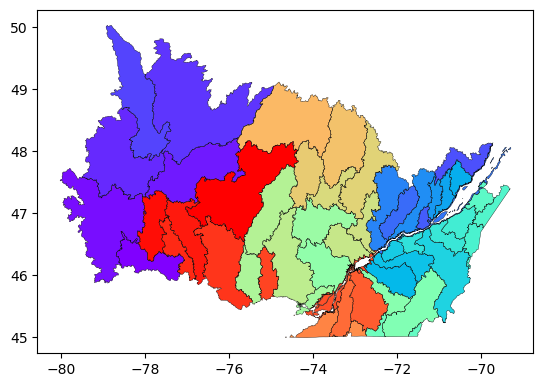

In [48]:
gdf = gpd.read_file(polygon_file).to_crs(epsg=4326)
gdf['colorfield'] = gdf.index
# empty plot
f, ax = plt.subplots(1,1)
# plot color
f = gdf.plot(ax=ax, column='colorfield', cmap='rainbow')
# plot boundary
f = gdf.boundary.plot(ax=ax, linewidth=0.25, color='k')

### **Step 3 – List available climate indicators for this dataset**

This step connects to the PAVICS / THREDDS catalog and builds a table of available precalculated climate indicators for the selected data source. The table includes a column for:

- variable IDs
- which temporal groupings the variables exist for (`annual`, `seasonal`, `monthly`, …)
- a description of each variable (`long_name`)

No need to modify the code; just scroll, filter, and search the table to decide what you want to extract later.


In [49]:
url = pavics_url[data_source]["url"]
chunks = pavics_url[data_source]["chunks"]

vars_dict = {}

print("Scanning the THREDDS catalog…")

for dd in tds.crawl(url, depth=100):
    # Only keep entries belonging to this data source
    if data_source not in dd.name:
        continue

    ds_tmp = xr.open_dataset(dd.opendap_url(), chunks=chunks, decode_timedelta=False)

    # set non-time variables as coordinates
    for vv in ds_tmp.data_vars:
        if "time" not in ds_tmp[vv].dims:
            ds_tmp = ds_tmp.assign_coords({vv: ds_tmp[vv]})

    # Try to infer the time frequency and convert to an interpretable label
    freq = xr.infer_freq(ds_tmp.time)
    if freq is None:
        continue

    freq = (
        freq.replace("YS", "annual")
        .replace("QS-DEC", "seasonal")
        .replace("2QS-OCT", "6month")
        .replace("MS", "monthly")
        .replace("annual-JAN", "annual")
        .replace("annual-JUL", "annual-julyjune")
    )

    # For CanDCS-M6, variables are often named like "ssp245_tx_mean".
    # We remove the scenario prefix so the variable ID is just "tx_mean".
    for vv in [v for v in ds_tmp.data_vars if "_consensus" not in v]:
        vv_out = vv if "ssp" not in vv else "_".join(vv.split("_")[1:])

        if vv_out not in vars_dict:
            vars_dict[vv_out] = {
                "season": [freq],
                "description": ds_tmp[vv].attrs.get("long_name", ""),
            }
        else:
            if freq not in vars_dict[vv_out]["season"]:
                vars_dict[vv_out]["season"].append(freq)

vars_table = pd.DataFrame.from_dict(vars_dict, orient="index").sort_index()
file_path = 'climatedata_vars.yml'
with open(file_path, 'r') as file:
    # Load the YAML content into a Python dictionary
    config_data = yaml.safe_load(file)
config_data['variables']
vars_table['climatedata.ca name'] = 'N/A'
for kk, vv in config_data['variables'].items():
    vars_table.at[vv, 'climatedata.ca name'] = kk.replace('_', ' ').capitalize()
vars_table = vars_table[["season", "climatedata.ca name", "description"]]
pn.Column(
    pn.pane.Markdown(f"## Available precalculated climate indicators for {data_source}"),
    pn.widgets.Tabulator(
        vars_table,
        header_filters=True,
        sortable=True,
        page_size=10,
        disabled=True,
        height=350,
    ),
)

Scanning the THREDDS catalog…


Column
    [0] Markdown(str)
    [1] Tabulator(disabled=True, header_filters=True, height=350, page_size=10, value=                          ...)

### **Step 4 – Choose which variables to extract**

Using the table above:

- Look up the variable IDs you want.
- Note which temporal grouping they use (`seasonal`, `monthly`, `annual`, …).

Then fill the `variables` dictionary:

- Keys = temporal grouping (`"seasonal"`, `"monthly"`, `"annual"`)
- Values = list of variable IDs that exist at that grouping (`"cdd"`, `"tg_mean"`, `"frost_free_season"`)

For the example in Step 8, we need seasonal total precipitation (prtot) data. You can edit the temporal grouping and the list of variable names based on what you want to analyze.

<div class="alert alert-success">
<strong>User input required below</strong> 
</div>

In [50]:
variables = {
    "seasonal": ["prtot"], 
    
    # you can change the temporal grouping and variables list based on your analysis of interest
    # "monthly":  ["tg_mean", "prx1day"],
    # "annual": ["tn_mean", "sn10mm", "pr1mm"],
    # ... 
}

print(variables)

{'seasonal': ['prtot']}


### **Step 5 – Locate and open the raw datasets**

Here, load the original ensemble data from the THREDDS catalog for each temporal grouping you requested (e.g. `"seasonal"`, `"monthly"`): 

1. Find the matching dataset(s) in the THREDDS catalog.
2. Open them with [xarray](https://docs.xarray.dev/en/stable/index.html), a Python library designed for working with labelled multi-dimensional arrays.
3. Store the result in a dictionary called `raw_datasets`, where the keys are the temporal groupings and the values are xarray.Dataset objects containing all available variables and scenarios for that grouping. 

You normally don't need to change the code here; simply run it to load the raw datasets before moving on to the next steps.


In [51]:
# Make sure things are Paths / lists
if isinstance(polygon_file, str):
    polygon_file = Path(polygon_file)

if isinstance(ssps, str):
    ssps = [ssps]

output_folder = Path(output_folder)
output_folder.mkdir(parents=True, exist_ok=True)

url = pavics_url[data_source]["url"]
chunks = pavics_url[data_source]["chunks"]

raw_datasets = {}

with ProgressBar():
    for season, var_list in variables.items():
        if not var_list:
            continue

        print(f"\n=== {season} ===")

        # Find the appropriate dataset on THREDDS for this temporal grouping
        season_descriptor = None
        for dd in tds.crawl(url, depth=100):
            if data_source not in dd.name:
                continue
            # In CanDCS-M6, filenames usually start with the temporal grouping:
            # e.g. "seasonal_", "monthly_", "annual_"
            if dd.name.split("_")[0] == season:
                season_descriptor = dd
                break

        if season_descriptor is None:
            print(f"  No dataset found for temporal grouping '{season}'. Skipping.")
            continue

        # open the dataset with xarray
        print(f"  Using dataset: {season_descriptor.name}")
        ds_raw = xr.open_dataset(
            season_descriptor.opendap_url(),
            chunks=chunks,
            decode_timedelta=False,
        )

        # set non-time variables as coordinates
        for vv in ds_raw.data_vars:
            if "time" not in ds_raw[vv].dims:
                ds_raw = ds_raw.assign_coords({vv: ds_raw[vv]})

        # Load coordinates in memory (helps with later operations)
        for cc in ds_raw.coords:
            ds_raw[cc] = ds_raw[cc].load()

        raw_datasets[season] = ds_raw

print("\nFinished opening raw datasets.")


=== seasonal ===
  Using dataset: seasonal_CanDCS-M6_climindices_ensemble_members.ncml

Finished opening raw datasets.


### **Step 6 – Subset by scenario and variable**

In this step, trim the raw datasets down to only the scenarios and variables you selected in the previous steps. The result is a dictionary called `subset_datasets`, where the keys are the temporal groupings you requested (e.g. `"seasonal"`, `"monthly"`), and the values are xarray.Dataset objects with dimensions `(scenario, realization, time, lat, lon)` that contain only the selected variables. In these datasets:
- `scenario` contains only the scenarios you specified in Step 1,
- `realization` labels the individual ensemble members,
- `time` is the time axis (e.g. yearly, seasonal, monthly values based on the temporal grouping),
- `lat` and `lon` describe the model grid over your region.


In [52]:
subset_datasets = {}

for season, var_list in variables.items():
    if season not in raw_datasets:
        continue
    if isinstance(var_list, str):
        var_list = [var_list]

    print(f"\n=== {season} – subsetting scenarios & variables ===")
    ds_raw = raw_datasets[season]
    season_dsets = []

    for ssp in ssps:
        print(f"  Scenario: {ssp}")

        # In CanDCS-M6, variables are named like "ssp245_tx_mean"
        var_names = [v for v in ds_raw.data_vars if v.startswith(ssp)]
        if not var_names:
            print(f"    No variables starting with '{ssp}_' found. Skipping.")
            continue

        ds_tmp = ds_raw[var_names]

        # Rename variables to drop the ssp prefix: "ssp245_tx_mean" → "tx_mean"
        rename_map = {v: "_".join(v.split("_")[1:]) for v in var_names}
        ds_tmp = ds_tmp.rename(rename_map)

        # Keep only the variables requested by the user
        ds_tmp = ds_tmp[[v for v in ds_tmp.data_vars if v in var_list]]

        # Add a `scenario` coordinate
        ds_tmp = ds_tmp.assign_coords(scenario=ssp).expand_dims("scenario")

        season_dsets.append(ds_tmp)

    if not season_dsets:
        print(f"No data retained for {season}.")
        continue

    if len(season_dsets) > 1:
        ds_season = xr.concat(season_dsets, dim="scenario")
    else:
        ds_season = season_dsets[0]

    # Make sure `realization` is a string
    if "realization" in ds_season.coords:
        ds_season["realization"] = ds_season["realization"].astype(str)

    subset_datasets[season] = ds_season

print("\nSubsetting by scenario and variable done.")


=== seasonal – subsetting scenarios & variables ===
  Scenario: ssp370

Subsetting by scenario and variable done.


Let's display the `subset_datasets` dictionnary to see its structure.

In [53]:
subset_datasets

{'seasonal': <xarray.Dataset> Size: 32GB
 Dimensions:      (scenario: 1, realization: 24, time: 604, lat: 510, lon: 1068)
 Coordinates:
   * lat          (lat) float64 4kB 41.04 41.12 41.21 41.29 ... 83.29 83.38 83.46
   * lon          (lon) float64 9kB -141.0 -140.9 -140.8 ... -52.21 -52.12 -52.04
   * time         (time) datetime64[ns] 5kB 1950-03-01 1950-06-01 ... 2100-12-01
   * realization  (realization) <U64 6kB 'ACCESS-CM2:r1i1p1f1' ... 'UKESM1-0-L...
   * scenario     (scenario) <U6 24B 'ssp370'
 Data variables:
     prtot        (scenario, realization, time, lat, lon) float32 32GB dask.array<chunksize=(1, 1, 604, 150, 150), meta=np.ndarray>
 Attributes: (12/74)
     Conventions:                    CF-1.7 CMIP-6.2
     activity_id:                    CMIP
     cat%3a_data_format_:            zarr
     cat%3aactivity:                 ScenarioMIP
     cat%3abias_adjust_institution:  PCIC
     cat%3abias_adjust_project:      CanDCS-M6
     ...                             ...
     

### **Step 7 – Process, save, and collect the final datasets**

In this step, each temporal grouping is processed and saved according to the options chosen in Step 1 (in particular `time_avg`, `ref_horizons`, `spatial_avg`, and `ensemble_percentiles`):

1. **Spatial subset**: data are clipped to the watershed polygon specified by polygon_file.
2. **Unit conversion**: temperature variables are converted from Kelvin to °C when required.
3. **Optional** 30-year climatologies (`time_avg = True`) and anomalies/deltas relative to the reference periods given in `ref_horizons`.
4. **Optional** spatial averaging over the region (`spatial_avg = True`).
5. **Optional** ensemble percentiles across members (`ensemble_percentiles = True`).
6. Save to **Zarr**, reopen, and store everything in a dictionary `ds`.
7. Export a **CSV** file for use in tools such as Excel.

There is no need to modify this code block; simply run the cell to generate the final processed datasets.


In [54]:
ds = {} 

(output_folder / data_source / "zarr").mkdir(parents=True, exist_ok=True)
(output_folder / data_source / "csv").mkdir(parents=True, exist_ok=True)

print("Processing and saving the final datasets. This may take some time to run...\n")

for season, ds_season in subset_datasets.items():
    print(f"\n==================== {season} ====================")

    outfile_base = f"{season}_{data_source}"
    if ensemble_percentiles:
        outfile_base += "_ensemble_percentiles"
    else:
        outfile_base += "_members"

    # 1) Spatial subset using the watershed polygon 
    print(f"Subsetting to polygon: {polygon_file.name}")
    
    # make sure longitude and latitude are CF-compliant so xscen can find them
    if "lon" in ds_season.coords and "lat" in ds_season.coords:
        ds_season["lon"].attrs.setdefault("standard_name", "longitude")
        ds_season["lon"].attrs.setdefault("units", "degrees_east")
        ds_season["lat"].attrs.setdefault("standard_name", "latitude")
        ds_season["lat"].attrs.setdefault("units", "degrees_north")
    else:
        raise ValueError(
            f"Could not find 'lon' and 'lat' coordinates in dataset. "
            f"Available coords: {list(ds_season.coords)}"
        )
        
    ds_season = subset(ds_season, method="shape", shape=polygon_file, buffer=0.1)

    # 2) Convert Kelvin → Celsius if needed 
    for v in ds_season.data_vars:
        units = ds_season[v].attrs.get("units", "")
        if units.upper() in ["K", "KELVIN", "DEGK"]:
            print(f"Converting {v} from {units} to degC")
            ds_season[v] = convert_units_to(ds_season[v], "degC")
            ds_season[v].attrs["units"] = "degC"
    
    # 3) Optional: 30-year climatologies and deltas 
    if time_avg:
        print("Calculating 30-year means and deltas...")
        outfile = outfile_base + "_30yAvg"

        periods = [1951, 2100]  # full period; you can change if you want
        step = 10               # one 30-year climatology every 10 years

        # 30-year rolling means (climatologies)
        ds30 = climatological_op(
            ds_season,
            window=30,
            op="mean",
            min_periods=25,
            rename_variables=False,
            periods=periods,
        )

        # deltas relative to reference horizons
        datasets = [ds30]

        if ref_horizons:
            # allow both a single string or a list
            if isinstance(ref_horizons, str):
                horizons = [ref_horizons]
            else:
                horizons = list(ref_horizons)

            for horizon in horizons:
                print(f"  Computing deltas relative to {horizon}...")
                ds_delta = compute_deltas(ds=ds30, reference_horizon=horizon)
                datasets.append(ds_delta)
        else:
            print(
                "  No reference horizons provided in `ref_horizons`. Only 30-year climatologies (no deltas) will be computed."
            )

        # Merge climatologies and any deltas that were created
        ds_season = xr.merge(datasets)

        # Unstack dates 
        ds_season = unstack_dates(ds_season, new_dim="season")
        ds_season = ds_season.isel(time=range(0, len(ds_season.time), step))

        # If 'horizon' has a season dimension, keep only one copy
        if "horizon" in ds_season and "season" in ds_season["horizon"].dims:
            ds_season["horizon"] = ds_season["horizon"].isel(season=0).squeeze()
    else:
        outfile = outfile_base
        ds_season = unstack_dates(ds_season, new_dim="season")

    # 4) Optional: spatial averaging over the polygon 
    if spatial_avg:
        print("Calculating spatial averages over the polygon…")
        outfile += f"_spatial-avg_{polygon_file.stem}"

        poly = gpd.read_file(polygon_file).to_crs(epsg=4326)
        region = dict(name=polygon_file.stem, method="shape", shape=poly)

        ny = len(ds_season.lat)
        nx = len(ds_season.lon)
        wgtfile = polygon_file.parent.joinpath(
            f"{data_source}_{nx}x{ny}_{polygon_file.stem}_weights.nc"
        )

        if "rlon" in ds_season.dims:
            if "crs" in ds_season.data_vars or "crs" in ds_season.coords:
                ds_season = ds_season.drop_vars("crs")

        ds_season = spatial_mean(
            ds_season,
            method="xesmf",
            region=region,
            kwargs={
                "filename": wgtfile,
                "skipna": True,
                "reuse_weights": wgtfile.exists(),
            },
        )

    # Clean up bounds-like coordinates
    ds_season = ds_season.drop_vars(
        [c for c in ds_season.coords if "bounds" in c],
        errors="ignore",
    ).squeeze()

    # Make sure scenario & season exist as dimensions
    for dim in ["scenario", "season"]:
        if dim not in ds_season.dims:
            ds_season = ds_season.expand_dims(dim)

    # 5) Optional: compute ensemble percentiles 
    if ensemble_percentiles:
        print("Computing ensemble percentiles…")
        ds_season = xens.ensemble_stats(
            ds_season,
            {"ensemble_percentiles": {"split": False}},
        )

    # 6) Save to Zarr and reopen 
    outzarr = output_folder / data_source / "zarr" / f"{outfile}.zarr"

    if not outzarr.exists():
        print(f"Saving to Zarr: {outzarr}")
        with Client(**dask_kwargs) as c:
            display(c) # display the Client dashboard link
            outchunks = {}
            for d in ds_season.dims:
                if d in pavics_url[data_source]["chunks"]:
                    outchunks[d] = pavics_url[data_source]["chunks"][d]
                elif d == 'geom':
                    outchunks[d] = 250
                else:
                    outchunks[d] = 1
            save_to_zarr(ds_season.chunk(outchunks), outzarr.with_suffix('.tmp.zarr'), mode='w')
        shutil.move(outzarr.with_suffix('.tmp.zarr'), outzarr)

    print("Re-opening Zarr…")
    ds_saved = xr.open_zarr(outzarr, decode_timedelta=False)
    ds[season] = ds_saved

    # 7) Export each temporal grouping dataset to a CSV
    outcsv = output_folder / data_source / "csv" / f"{outzarr.stem}.csv"
    outmetacsv = output_folder / data_source / "csv" / f"{outzarr.stem}.metadata.csv"
    with ProgressBar():    
        print(f"Exporting to CSV : {outcsv}")
        outcsv.parent.mkdir(exist_ok=True)
        ddf = ds_saved.unify_chunks().to_dask_dataframe()
        ddf.to_csv(outcsv, single_file=True)

        # save metadata CSV
        print(f"Saving the CSV containing the metadata : {outmetacsv}")
        meta = {}
        for v in ds_saved.data_vars:
            meta[v] = {}
            for k in ["units", "long_name", "description"]:
                if k in ds_saved[v].attrs:
                    meta[v][k] = ds_saved[v].attrs[k]
        meta_df = pd.DataFrame.from_dict(meta).T
        meta_df.to_csv(outmetacsv)

print("\nAll done. The final datasets are stored in the dictionary `ds`.")
print("Keys:", list(ds.keys()))

Processing and saving the final datasets. This may take some time to run...


==================== seasonal ====================
Subsetting to polygon: watersheds_southernQC.shp
Calculating 30-year means and deltas...
  Computing deltas relative to 1981-2010...
  Computing deltas relative to 1991-2020...
Calculating spatial averages over the polygon…
Re-opening Zarr…
Exporting to CSV : output_SouthernQC/CanDCS-M6/csv/seasonal_CanDCS-M6_members_30yAvg_spatial-avg_watersheds_southernQC.csv
[########################################] | 100% Completed | 3.90 sms
Saving the CSV containing the metadata : output_SouthernQC/CanDCS-M6/csv/seasonal_CanDCS-M6_members_30yAvg_spatial-avg_watersheds_southernQC.metadata.csv

All done. The final datasets are stored in the dictionary `ds`.
Keys: ['seasonal']


### **Step 8 – Analyze and visualize the extracted data**

This example demonstrates how to analyze and visualize the indicator data extracted in the previous steps.

#### **Example: Visualize baseline vs future seasonal patterns of total precipitation**

In this example, the goal is to:

1. Use the **seasonal total accumulated precipitation** variable (`prtot`) that we extracted earlier.
2. Focus on **30-year baseline and future periods** (e.g., 1991–2020 vs 2071-2100) 
3. Select a **region** within the watershed.
4. Compute the **seasonal mean total accumulated precipitation** over the baseline and future periods.
5. Create a **grouped boxplot** comparing baseline and future seasonal patterns of total precipitation.

First, select the seasonal dataset from the `ds` dictionary we created in the previous step. Save this dataset as `ds_seasonal`. Then display its structure to examine its dimensions, coordinates, and variables.

In [30]:
ds_seasonal = ds["seasonal"]
print(ds_seasonal)

<xarray.Dataset> Size: 2MB
Dimensions:                (geom: 59, time: 13, scenario: 1, season: 4,
                            realization: 24)
Coordinates:
  * geom                   (geom) int64 472B 0 1 2 3 4 5 6 ... 53 54 55 56 57 58
    horizon                (time) object 104B dask.array<chunksize=(13,), meta=np.ndarray>
    id                     (geom) int32 236B dask.array<chunksize=(59,), meta=np.ndarray>
    label_en               (geom) object 472B dask.array<chunksize=(59,), meta=np.ndarray>
    label_fr               (geom) object 472B dask.array<chunksize=(59,), meta=np.ndarray>
    lat                    (geom) float64 472B dask.array<chunksize=(59,), meta=np.ndarray>
    lon                    (geom) float64 472B dask.array<chunksize=(59,), meta=np.ndarray>
  * realization            (realization) <U64 6kB 'ACCESS-CM2:r1i1p1f1' ... '...
  * scenario               (scenario) <U6 24B 'ssp370'
  * season                 (season) <U3 48B 'MAM' 'JJA' 'SON' 'DJF'
  * time   

The final dataset `ds["seasonal"]` contains the processed seasonal total precipitation for the selected watershed, along with changes (deltas) relative to the chosen reference periods.

**Dimensions**:
  - `time` (13): start years of each 30-year climatological period (e.g. `"1951-01-01"` for `"1951-1980"`).  
  - `season` (4): the four seasons `MAM`, `JJA`, `SON`, `DJF`.  
  - `scenario` (1): the emission scenario (here: `ssp370`).  
  - `realization` (24): the individual ensemble members (one per model / member combination).  
  - `geom` (59): sub-regions inside the watershed (e.g. individual basins or administrative units).

**Key coordinates**:
  - `label_en`, `label_fr`: English and French names of each region (`geom`); these labels come directly from the input shapefile and may vary depending on the shapefile used.
  - `lat`, `lon`: representative coordinates for each region.  
  - `horizon`: label describing each 30-year period separated by 10 years (e.g. `"1951-1980"`, `"1961-1990"`, ..., `"2071-2100"`).

**Data variables**:
  - `prtot`: 30-year mean seasonal total precipitation for each combination of (scenario, time period, season, realization, region).  
  - `prtot_delta_1981_2010`: change in `prtot` relative to the 1981–2010 reference period.  
  - `prtot_delta_1991_2020`: change in `prtot` relative to the 1991–2020 reference period.

In this dataset, the `geom` dimension indexes the individual regions inside the selected watershed. To choose a region for the analysis, start by listing the available region names using the `label_en` coordinate. Keep in mind that these names are shapefile specific (i.e., they reflect the attributes of the shapefile you provided).

In [31]:
print(ds_seasonal['label_en'].values)

['Central Ottawa - Dumoine' 'Upper Ottawa - Kipawa'
 'Upper Ottawa - Headwaters' 'Upper Ottawa - KinojÃ©vis' 'Bell'
 'Upper Harricanaw' 'Malbaie' 'Montmorency' 'Sainte-Anne' '' 'Batiscan'
 'Jacque-Cartier' 'Montmorency' 'Lower St. Lawrence - Gouffre'
 'Lower St. Lawrence - Gouffre' 'Nicolet' 'BÃ©cancour'
 'Lower St. Lawrence - ChÃªne' 'ChaudiÃ¨re' ''
 'Lower St. Lawrence - ChÃªne' 'Etchemin' 'Etchemin'
 'Headwaters Saint John' 'Upper Saint John - Big Black'
 'Lower St. Lawrence - Loup' '' 'Lake Champlain' ''
 'Upper Saint-FranÃ§ois' 'Lower Saint-FranÃ§ois' "L'Assomption" 'Matawin'
 'Montreal Island' 'Lower LiÃ¨vre' 'Upper LiÃ¨vre' 'Rouge and Nord' 'Loup'
 'Lower Saint-Maurice' 'Vermillon (Que.)' 'Central Saint-Maurice'
 'Manouane' 'Upper Saint-Maurice' 'Headwaters Saint-Maurice'
 'Upper St. Lawrence - Raisin' 'Upper St. Lawrence - Raisin'
 'Upper St. Lawrence - Raisin' 'Lake Champlain' 'Montreal Island'
 'Lower Ottawa - South Nation' 'Richelieu' 'Yamaska' '' 'Petite Nation'
 'Lower Gat

Next, specify the variable, the region name, the period you want to analyze and the folder where the final figure will be saved.
<div class="alert alert-success">
<strong>User input required below</strong> 
</div>


In [55]:
# === Change only the values on the right-hand side of the `=` signs. ====
analyze_variable = "prtot"
analyze_region = "Central Ottawa - Dumoine"
baseline_period = "1991-2020"
future_period = "2071-2100"
fig_folder = "figures"

In [56]:
# find the index of the geometry that matches your watershed's label
# call .compute() to convert lazy (dask) array to a concrete (numpy) array 
# this is because xarray doesn't support indexing with boolean dask arrays
geom_index = (ds_seasonal['label_en'] == analyze_region).compute()

# use the computed boolean index to select the matching geometry using .isel()
regional_ds = ds_seasonal.isel(geom=geom_index)

# from the regional_ds, subset the selected periods. to do this, first, build a boolean (True or False) mask along the time dimension using 'horizon'
baseline_mask = (regional_ds["horizon"] == baseline_period).compute()  # again, convert dask array to a numpy array with .compute()
future_mask = (regional_ds["horizon"] == future_period).compute()

# use the mask to keep only the desired horizon and drop data for the other horizons
baseline_data = regional_ds[analyze_variable].where(baseline_mask, drop=True)
future_data = regional_ds[analyze_variable].where(future_mask, drop=True)

# this leaves a length-1 time dimension showing the start year of the selected horizon, so you can squeeze it:
baseline_data = baseline_data.squeeze("time")
future_data = future_data.squeeze("time")

# extract the season values from ds_seasonal
seasons_list = ds_seasonal['season'].values

# initialize an empty list to store variable data for each season and period (baseline & future)
rows = []

# loop through each season (e.g., 'MAM' 'JJA' 'SON' 'DJF')
for ss in seasons_list:
    # convert the the multidimensional array into a 1D array using .ravel()
    # this is convenient for plotting tools such as seaborn.boxplot() 
    seasonal_baseline_data = baseline_data.sel(season=ss).values.ravel()
    seasonal_future_data   = future_data.sel(season=ss).values.ravel()
    
    # extend the list with seasonal data 
    rows.extend([(ss, "Baseline", data) for data in seasonal_baseline_data])
    rows.extend([(ss, "Future", data) for data in seasonal_future_data])

# creates a two-dimensional (rows and columns), tabular data structure using pd.DataFrame
# we'll use this data frame to create grouped boxplots 
df_long = pd.DataFrame(rows, columns=["Season", "Period", "Value"])

Let's display `df_long` to see the labeled rows and columns. 

In [34]:
df_long

,Season,Period,Value
0,MAM,Baseline,207.101059
1,MAM,Baseline,208.872772
2,MAM,Baseline,211.721100
3,MAM,Baseline,216.599548
4,MAM,Baseline,214.513992
...,...,...,...
187,DJF,Future,254.985367
188,DJF,Future,258.924805
189,DJF,Future,274.309662
190,DJF,Future,253.752197


Finally, let's create a grouped boxplot comparing the seasonal distribution of total precipitation during the baseline and future periods. Add axis labels and a title, then save the figure in the specified output folder.

Figure saved to figures/boxplot_prtot_CanDCS-M6.png


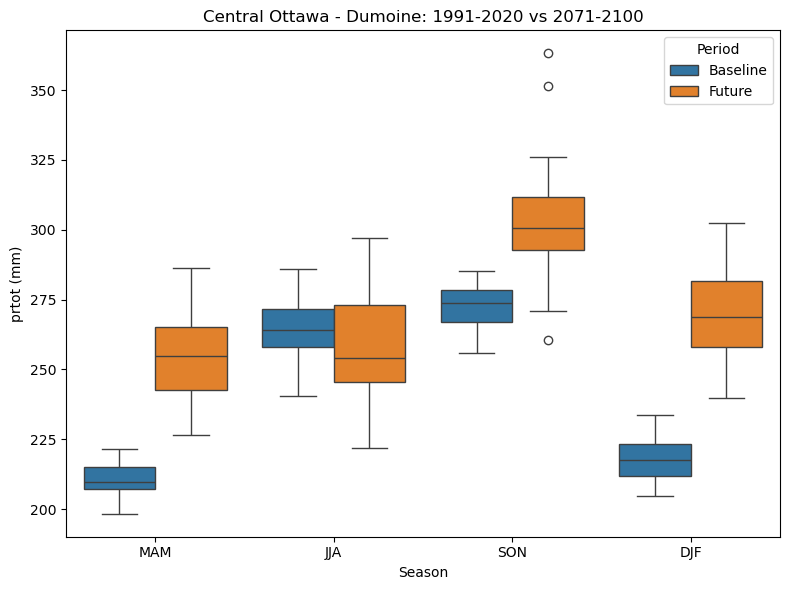

In [57]:
# import the plotting libraries
import matplotlib.pyplot as plt
import seaborn as sns 

# set the figure size
plt.figure(figsize=(8, 6)) 

# plot grouped boxplots: each Season on x-axis, Value on y-axis, split by Period (hue)
sns.boxplot(
    x="Season",
    y="Value",
    hue="Period",
    data=df_long,
)

# get the unit attribute
unit = getattr(baseline_data, "units", "Unknown")

# Labels and title
plt.xlabel("Season")
plt.ylabel(f"{analyze_variable} ({unit})")
plt.title(f"{analyze_region}: {baseline_period} vs {future_period}")

# adjust layout to prevent overlap
plt.tight_layout()  

# save the figure
fig_folder = Path("figures")
fig_folder.mkdir(exist_ok=True)   # create folder if it doesn't exist
fig_path = fig_folder / f"boxplot_{analyze_variable}_{data_source}.png"
plt.savefig(fig_path)
print(f'Figure saved to {fig_path}')

plt.show()

### **Bonus Material**
Using a spatially averaged output:
* Add data columns to original polygon layer 
* Export to geojson (or shapefile)
* Create interactive plots in the PAVICS environments

In [58]:
from cartopy import crs as ccrs
# compare regridded to original

# export only the ensemble median : could add [10, 50, 90]
keep_perc = [50]

# path to the shapefile we've been using
polygon_original_file =Path("GIS-Data/watersheds/watersheds_southernQC.shp")

# loop over our associtated .zarr output 
for zarr in output_folder.joinpath(data_source, 'zarr').glob(f'*30yAvg_spatial-avg_{polygon_original_file.stem}.zarr'):
    print(zarr)
    # load the data
    gdf = gpd.read_file(polygon_original_file).to_crs(epsg=4326)
    ds1 = xr.open_zarr(zarr, decode_timedelta=False)
    
    if 'realization' in ds1.dims:
        ds1 = xens.ensemble_stats(
            ds1,
            {"ensemble_percentiles": {"split": False}},
        )
   
    #define output shp file path
    outpoly = output_folder.joinpath(data_source, 'geojson', f"{zarr.stem}.geojson")
    # create parent directory
    outpoly.parent.mkdir(exist_ok=True, parents=True)
    
    # concatenate data as shpfile columns
    for vv in ds1.data_vars:
        for ssp in ds1.scenario.values:
            for seas in ds1.season.values:
                for hh in ds1.horizon.values:
                    for perc in keep_perc:
                        # define column name
                        vvv = f"{vv}-{seas}-{hh}-{ssp}_p{perc}"
                        # get data values
                        data = ds1[vv].sel(season=seas, scenario=ssp, percentiles=perc, time=(ds1.horizon == hh)).squeeze()
                        # get units as well
                        units = data.attrs['units']
                        # convert to pandas df
                        data = data.to_dataframe()
                        # append new data column to polygon layer
                        gdf[f"{vvv} ({units})"] = data[vv]
    #export to geojson
    gdf.to_file(outpoly, driver="GeoJSON")      


output_SouthernQC/CanDCS-M6/zarr/seasonal_CanDCS-M6_members_30yAvg_spatial-avg_watersheds_southernQC.zarr


Let's take a look at the output.

In [37]:
print(outpoly)
gdf = gpd.read_file(outpoly)
gdf.head()

output_SouthernQC/CanDCS-M6/geojson/seasonal_CanDCS-M6_members_30yAvg_spatial-avg_watersheds_southernQC.geojson


,id,label_en,label_fr,prtot-MAM-1951-1980-ssp370_p50 (mm),prtot-MAM-1961-1990-ssp370_p50 (mm),prtot-MAM-1971-2000-ssp370_p50 (mm),prtot-MAM-1981-2010-ssp370_p50 (mm),prtot-MAM-1991-2020-ssp370_p50 (mm),prtot-MAM-2001-2030-ssp370_p50 (mm),prtot-MAM-2011-2040-ssp370_p50 (mm),...,prtot_delta_1991_2020-DJF-1991-2020-ssp370_p50 (mm),prtot_delta_1991_2020-DJF-2001-2030-ssp370_p50 (mm),prtot_delta_1991_2020-DJF-2011-2040-ssp370_p50 (mm),prtot_delta_1991_2020-DJF-2021-2050-ssp370_p50 (mm),prtot_delta_1991_2020-DJF-2031-2060-ssp370_p50 (mm),prtot_delta_1991_2020-DJF-2041-2070-ssp370_p50 (mm),prtot_delta_1991_2020-DJF-2051-2080-ssp370_p50 (mm),prtot_delta_1991_2020-DJF-2061-2090-ssp370_p50 (mm),prtot_delta_1991_2020-DJF-2071-2100-ssp370_p50 (mm),geometry
0,164,Central Ottawa - Dumoine,Cours moyen de la riviÃ¨re des Outaouais - Dum...,204.068909,202.699432,203.815254,206.843040,209.731995,214.211754,220.378746,...,0.0,6.790922,10.921194,18.001000,20.729833,29.204857,36.935127,40.494856,51.470175,"POLYGON ((-77.52054 46.33356, -77.51661 46.330..."
1,163,Upper Ottawa - Kipawa,Cours supÃ©rieur de la riviÃ¨re des Outaouais ...,203.445282,202.036797,204.103668,207.418663,210.510513,215.334236,221.855499,...,0.0,6.631595,10.853073,20.968896,20.873585,33.281506,42.359179,42.220257,55.117289,"POLYGON ((-78.97184 45.88133, -78.97215 45.884..."
2,159,Upper Ottawa - Headwaters,Cours supÃ©rieur de la riviÃ¨re des Outaouais ...,199.796486,198.500732,200.324356,203.269493,208.051338,211.591232,218.481293,...,0.0,7.904333,11.222969,19.077237,18.916952,33.148941,42.139702,44.602346,55.904694,"POLYGON ((-77.98182 47.26333, -77.98779 47.268..."
3,160,Upper Ottawa - KinojÃ©vis,Cours supÃ©rieur de la riviÃ¨re des Outaouais ...,191.450912,191.777077,192.034729,195.604263,200.096657,203.464104,209.215195,...,0.0,6.477738,10.770816,18.470698,19.973927,32.737450,41.057497,41.466543,53.059479,"POLYGON ((-77.98182 47.26333, -77.98735 47.260..."
4,298,Bell,Bell,184.937355,185.878738,186.795151,190.481728,194.374573,197.509575,203.139252,...,0.0,7.966136,10.522722,18.421567,19.933004,32.558105,39.748846,44.951992,54.759205,"POLYGON ((-75.79143 48.20757, -75.80578 48.208..."


Plot the ensemble median of average winter total precipitation for sub-basins for baseline and future periods.

In [38]:
# baseline period
h1 = '1991-2020'
# future period 
h2 = '2071-2100'

# variable for baseline period
var1 = f'prtot-DJF-{h1}-ssp370_p50 (mm)'
# variable for fututure period
var2 = f'prtot-DJF-{h2}-ssp370_p50 (mm)'

# set color limits (min and max of our two variables)
clim = (gdf[[var1, var2]].min().min(), gdf[[var1, var2]].max().max())

# plot interactive map
gdf.hvplot(c=var1, clim=clim, geo=True, tiles='CartoLight', alpha=0.65, title=h1, cmap='spectral') \
+ gdf.hvplot(c=var2, clim=clim, geo=True, tiles='CartoLight', alpha=0.65, title=h2, cmap='spectral')

:Layout
   .Overlay.I  :Overlay
      .WMTS.I     :WMTS   [Longitude,Latitude]
      .Polygons.I :Polygons   [Longitude,Latitude]   (prtot-DJF-1991-2020-ssp370_p50 (mm))
   .Overlay.II :Overlay
      .WMTS.I     :WMTS   [Longitude,Latitude]
      .Polygons.I :Polygons   [Longitude,Latitude]   (prtot-DJF-2071-2100-ssp370_p50 (mm))